In [79]:
import sys
sys.path.append('../')

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from helpers_mom6.collection_of_experiments import CollectionOfExperiments
from helpers.plot_helpers import *
from helpers_mom6.computational_tools import remesh, select_LatLon, Lk_error, x_coord, y_coord, gaussian_remesh
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
import os

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore")
import hvplot.xarray
import hvplot
hvplot.output(widget_location='bottom')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
ds = CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Feb2022/bare', additional_subfolder='output')

In [81]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Apr2023/generalization', additional_subfolder='output')

In [82]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/Apr2023/GZ21_results', additional_subfolder='')

In [83]:
ds += CollectionOfExperiments.init_folder('/scratch/pp2681/mom6/CM26_Double_Gyre/generalization', additional_subfolder='output')

In [84]:
for exp in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']:
    ds.remesh('R64', exp)

Experiment R64 coarsegrained to R2 is created. Its identificator=R64_R2
Experiment R64 coarsegrained to R3 is created. Its identificator=R64_R3
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4
Experiment R64 coarsegrained to R5 is created. Its identificator=R64_R5
Experiment R64 coarsegrained to R6 is created. Its identificator=R64_R6
Experiment R64 coarsegrained to R7 is created. Its identificator=R64_R7
Experiment R64 coarsegrained to R8 is created. Its identificator=R64_R8


In [9]:
for FGR in ['1.0', '1.5', '2.0', '2.5', '3.0']:
    ds.remesh('R64', 'R4', f'R64_R4_FGR{FGR}', operator= lambda x,y: gaussian_remesh(x,y,FGR=float(FGR)))
    for file in [f'/scratch/pp2681/mom6/Double-Gyre-offline/R64_R4_FGR{FGR}-part1.nc', f'/scratch/pp2681/mom6/Double-Gyre-offline/R64_R4_FGR{FGR}-part2.nc']:
        pass
        dataset = xr.open_dataset(file, decode_times=False)
        for key in dataset.keys():
            setattr(ds[f'R64_R4_FGR{FGR}'], key, dataset[key])

Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4_FGR1.0
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4_FGR1.5
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4_FGR2.0
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4_FGR2.5
Experiment R64 coarsegrained to R4 is created. Its identificator=R64_R4_FGR3.0


In [10]:
len(ds.exps)

2106

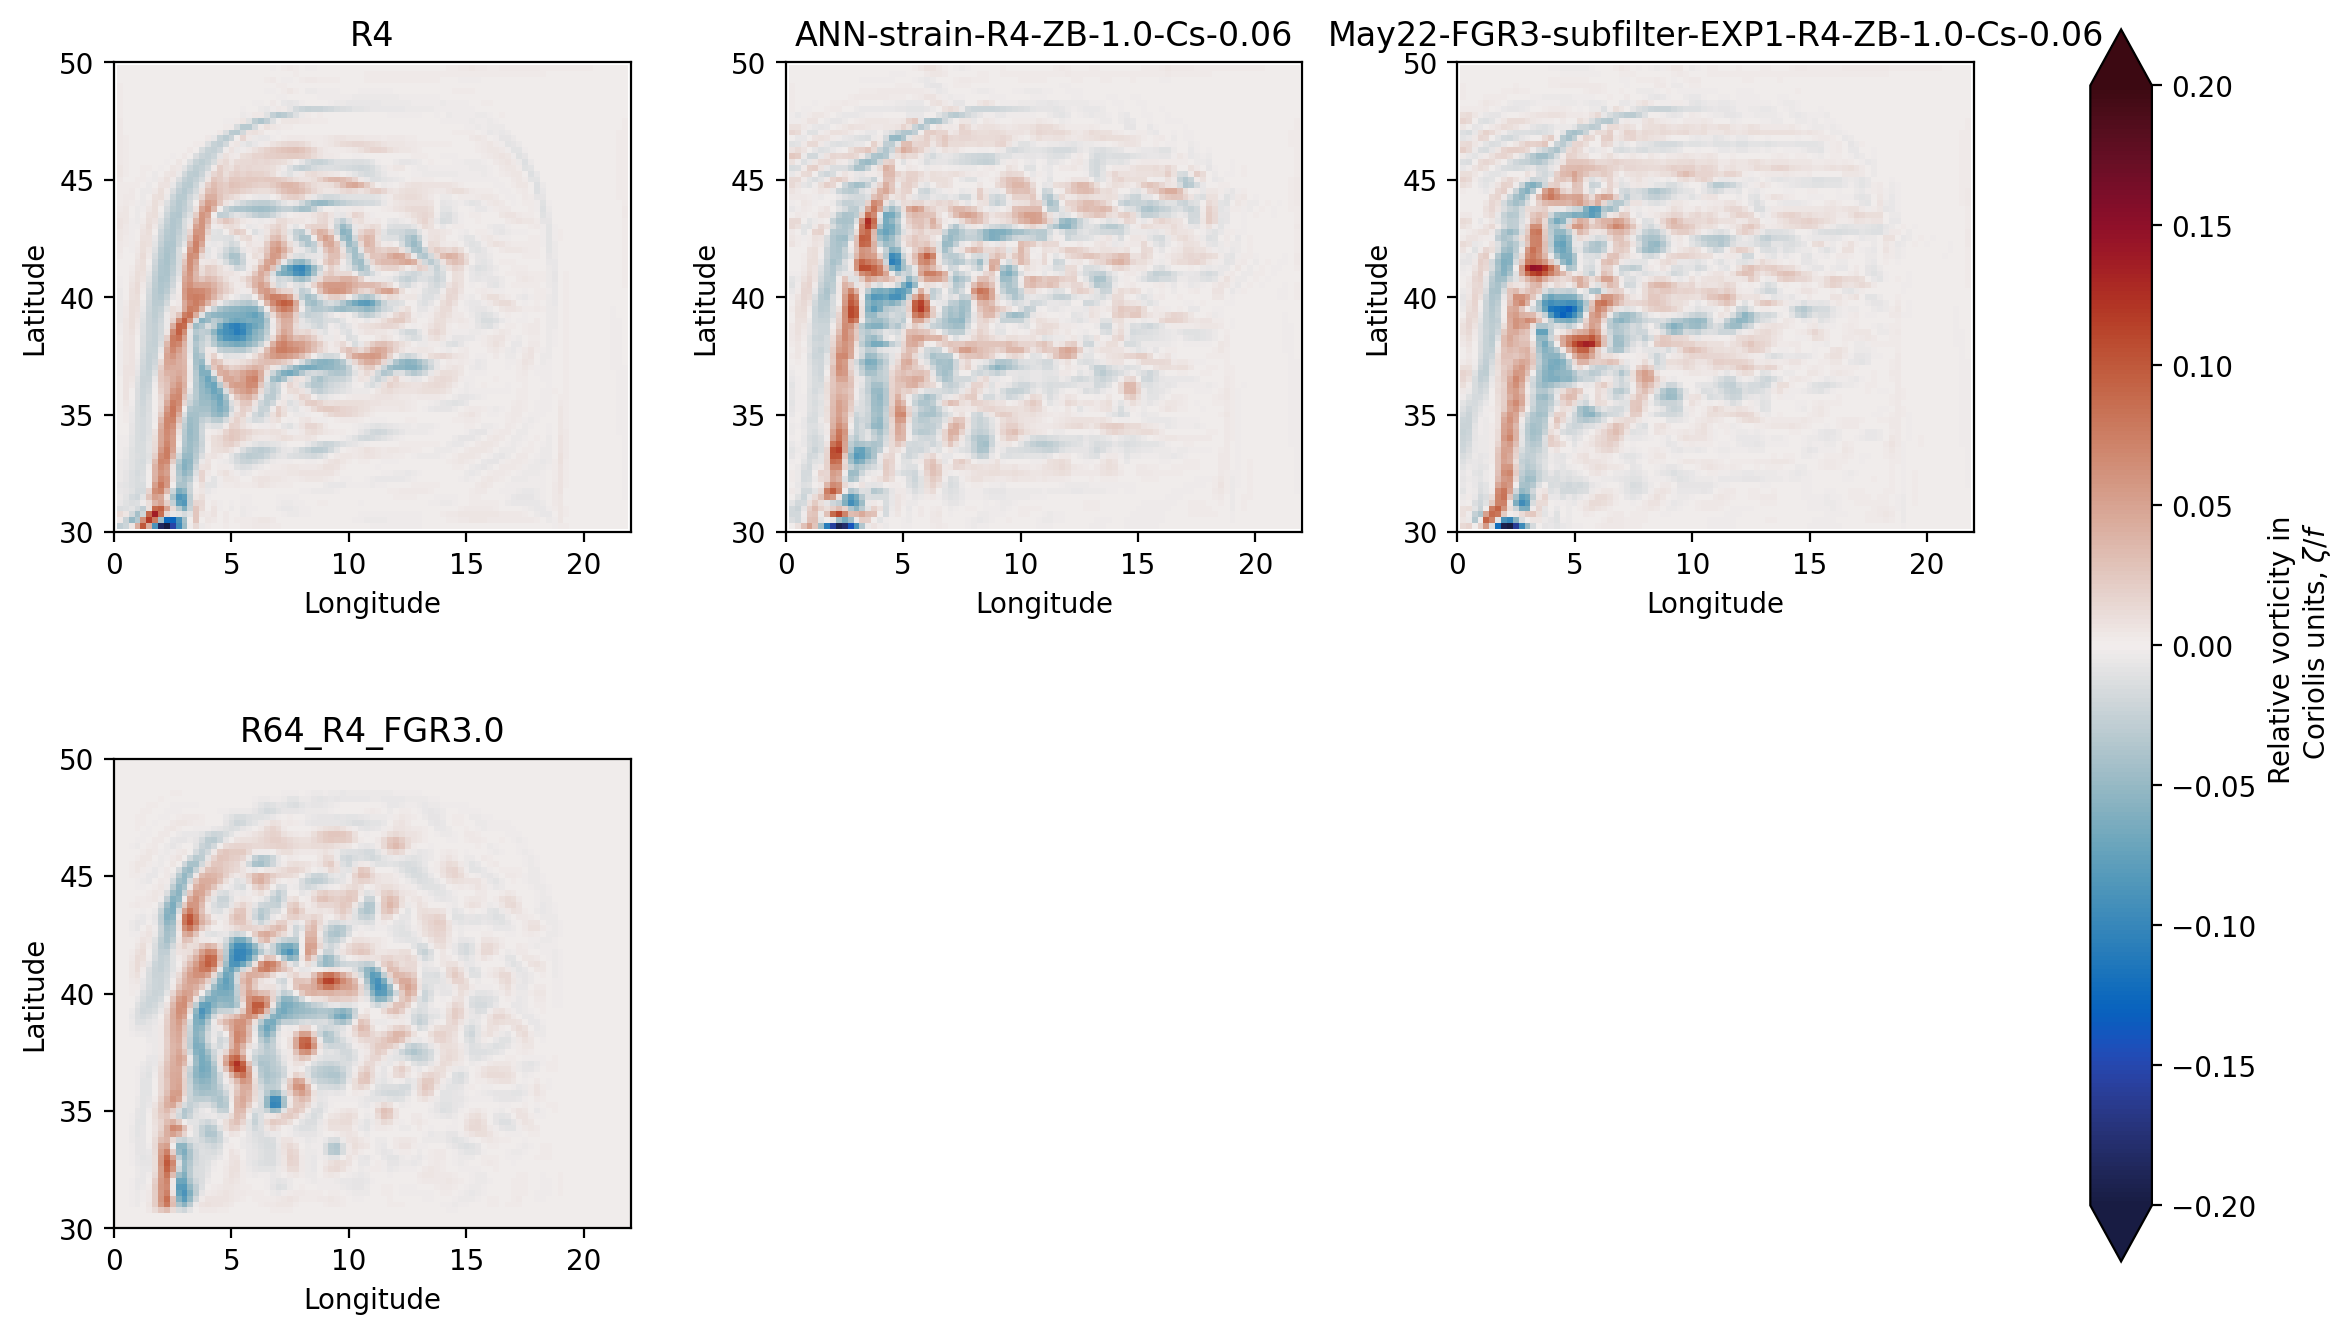

In [29]:
ds.plot_RV(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0'])

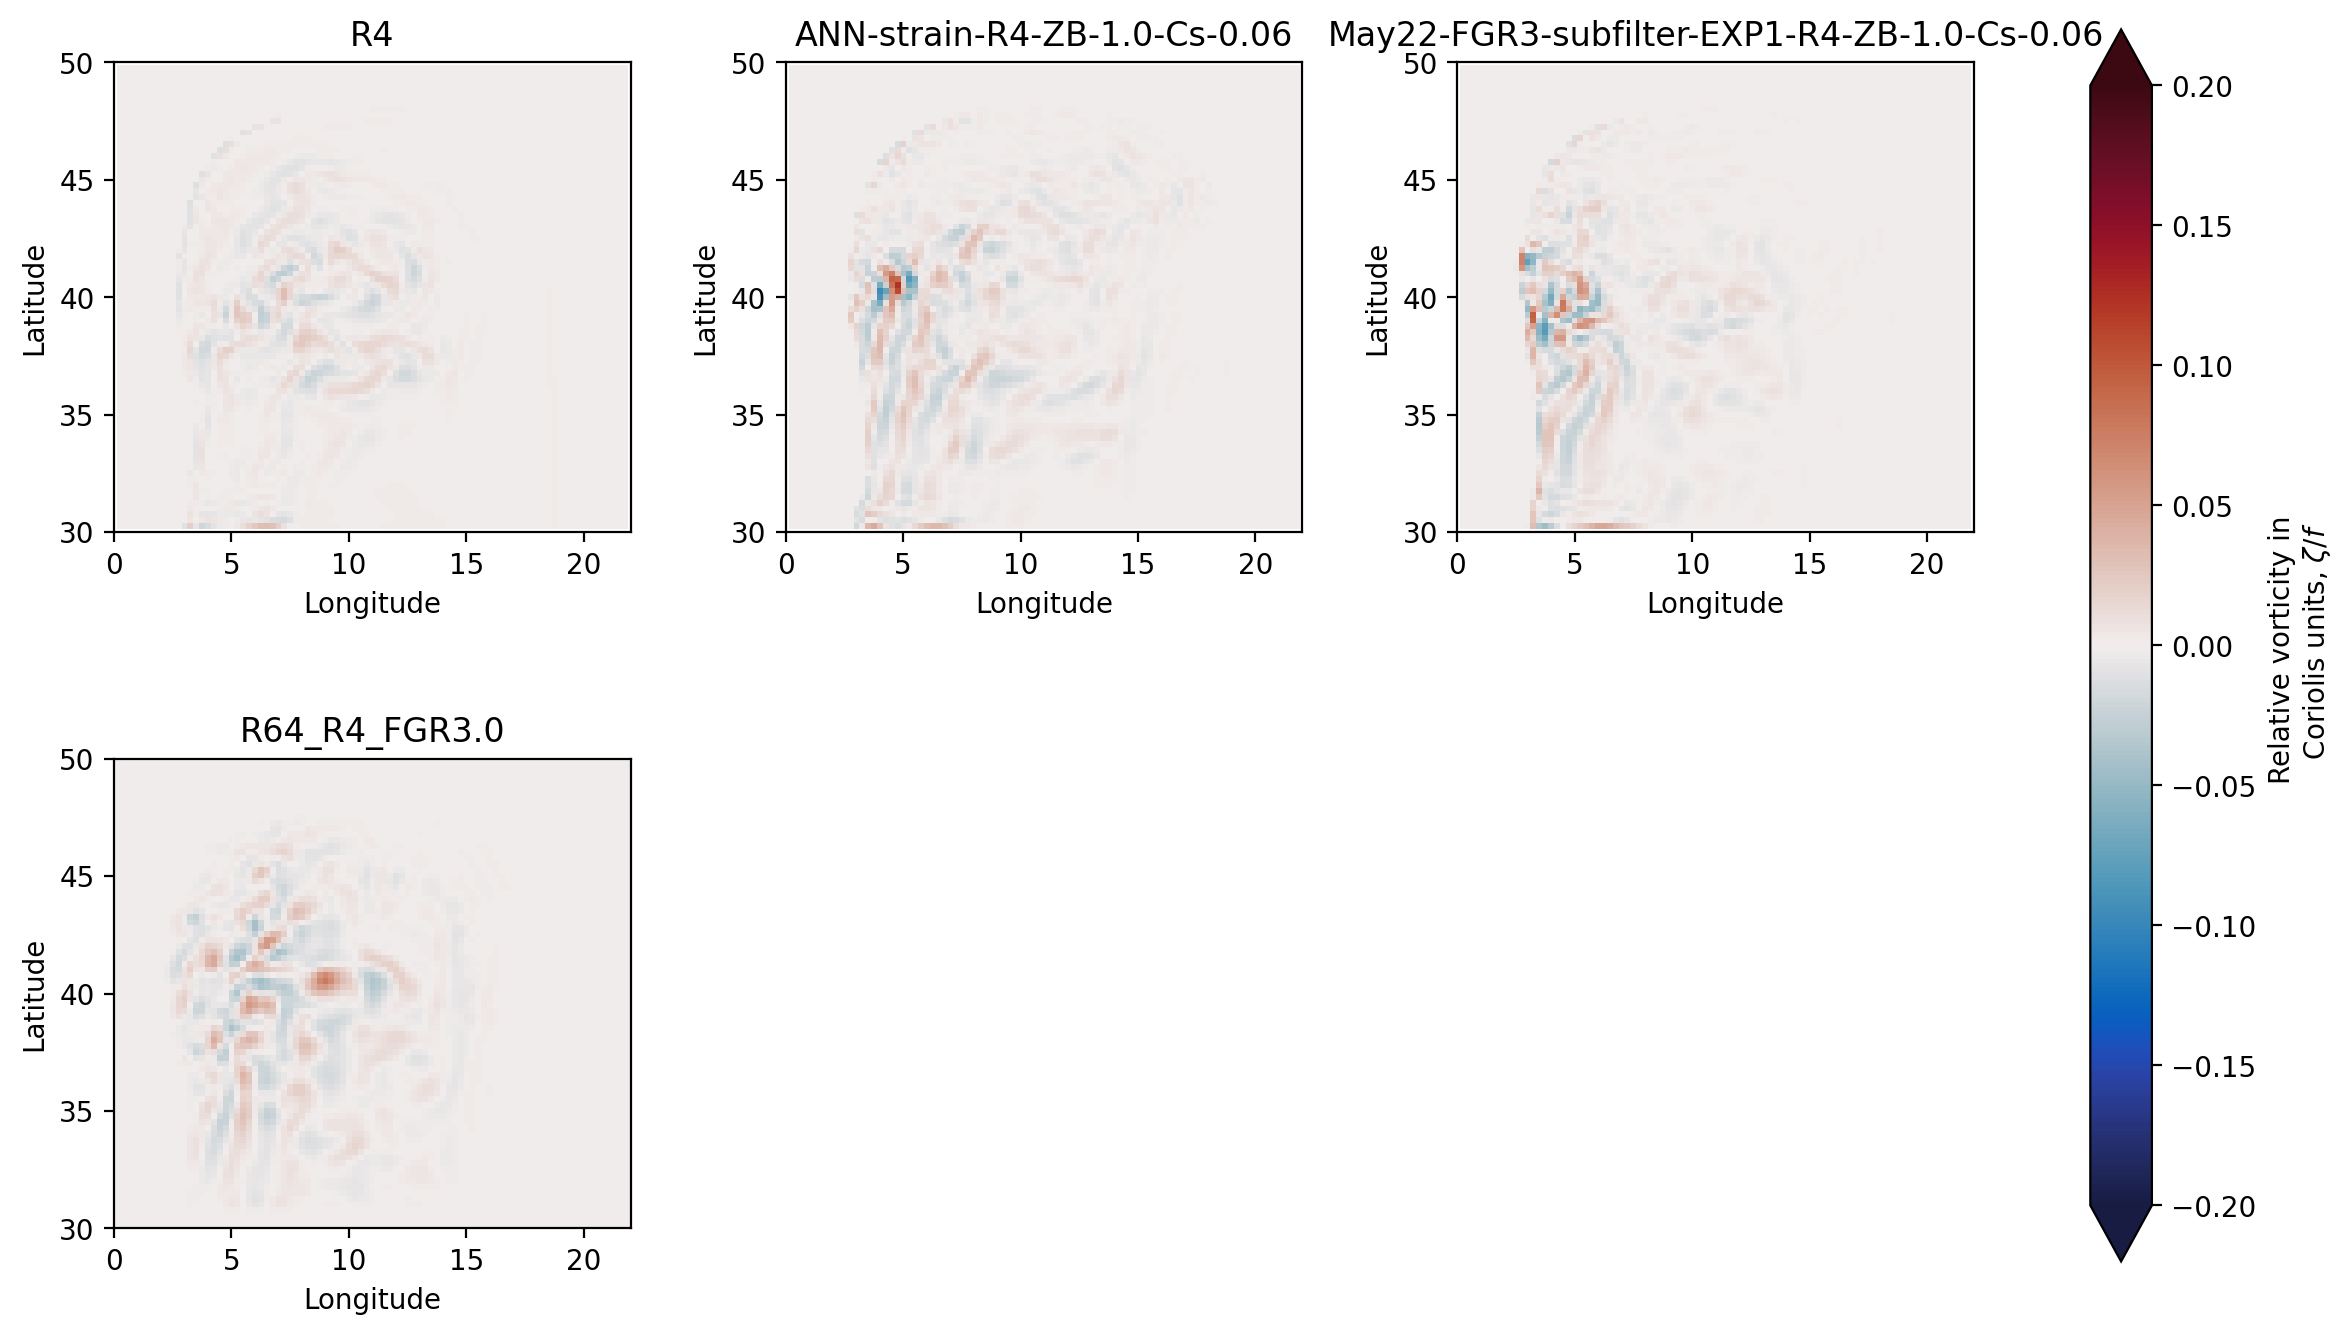

In [30]:
ds.plot_RV(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0'], zl=1)

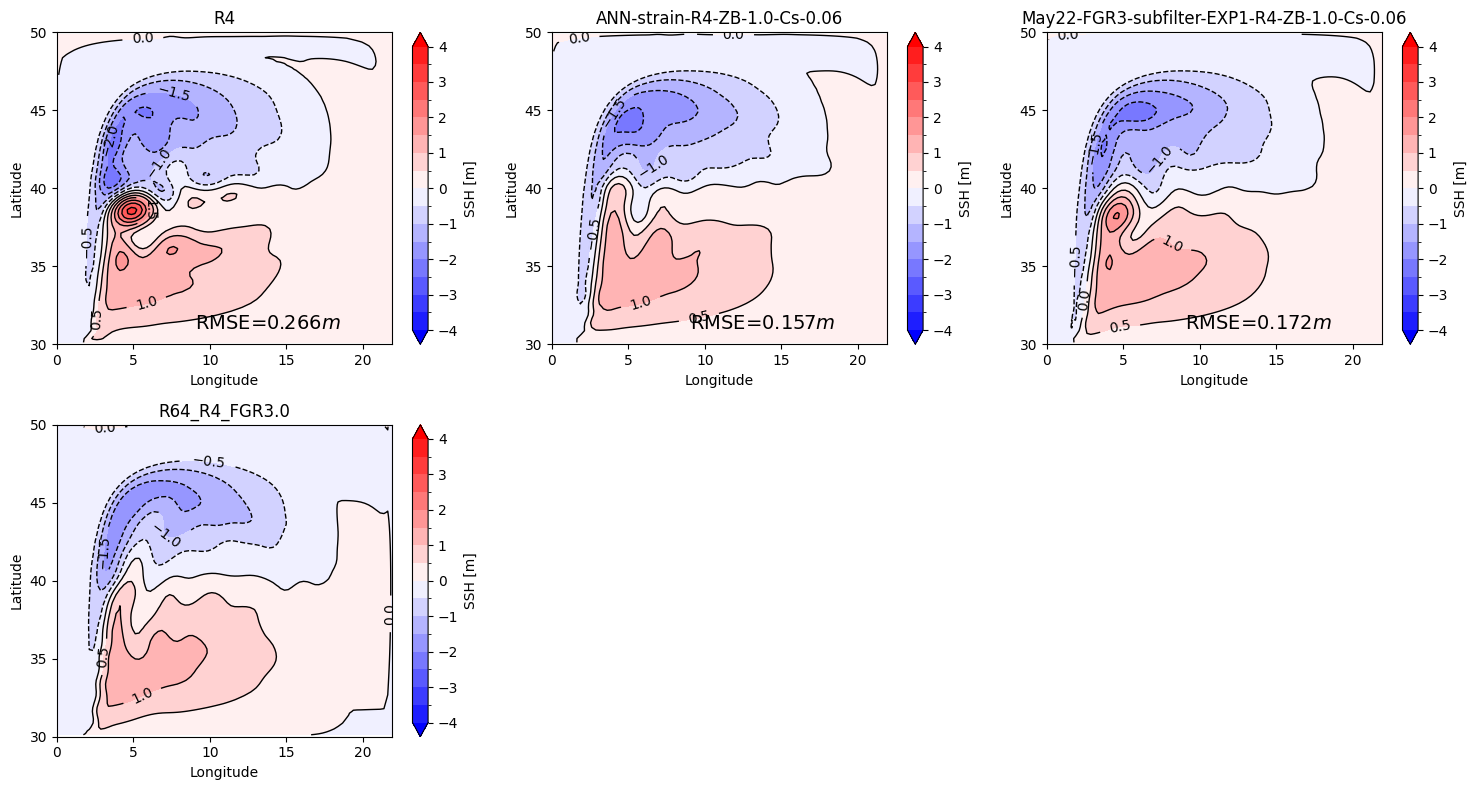

In [31]:
ds.plot_ssh(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0'])

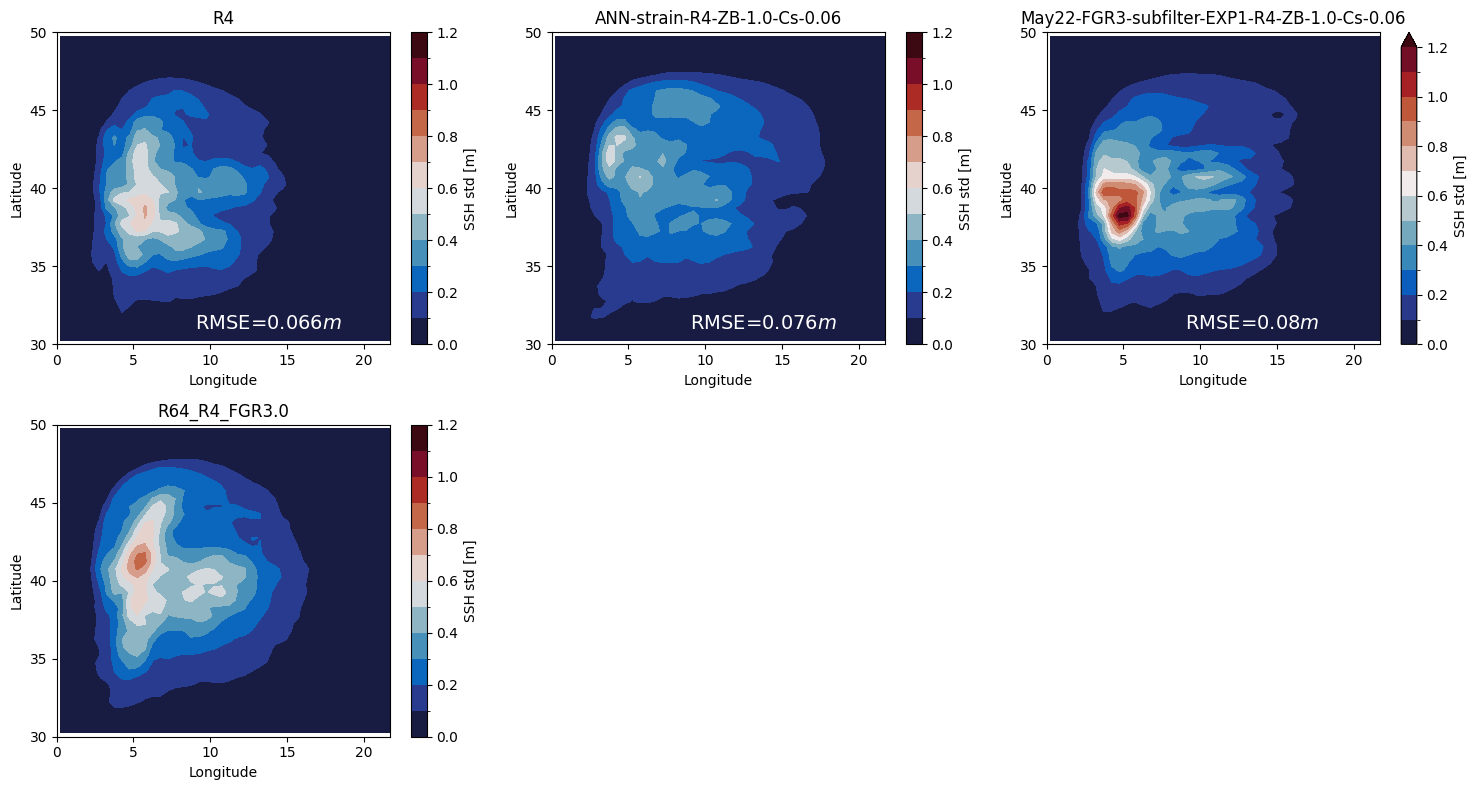

In [32]:
ds.plot_ssh_std(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0'])

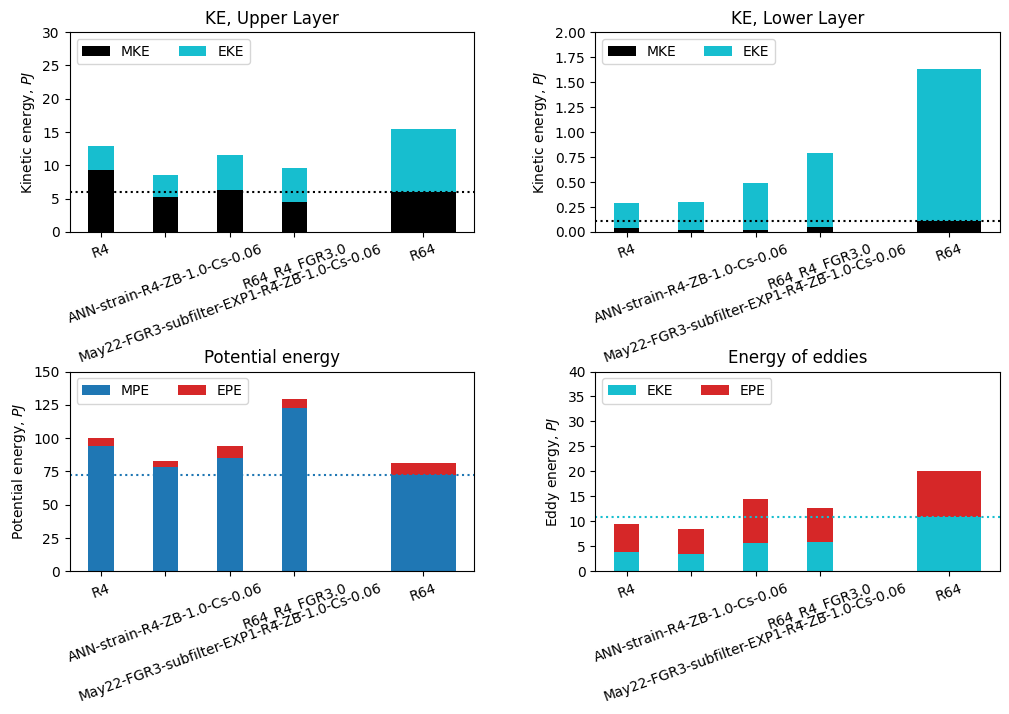

In [35]:
ds.plot_KE_PE(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0', 'R64'])

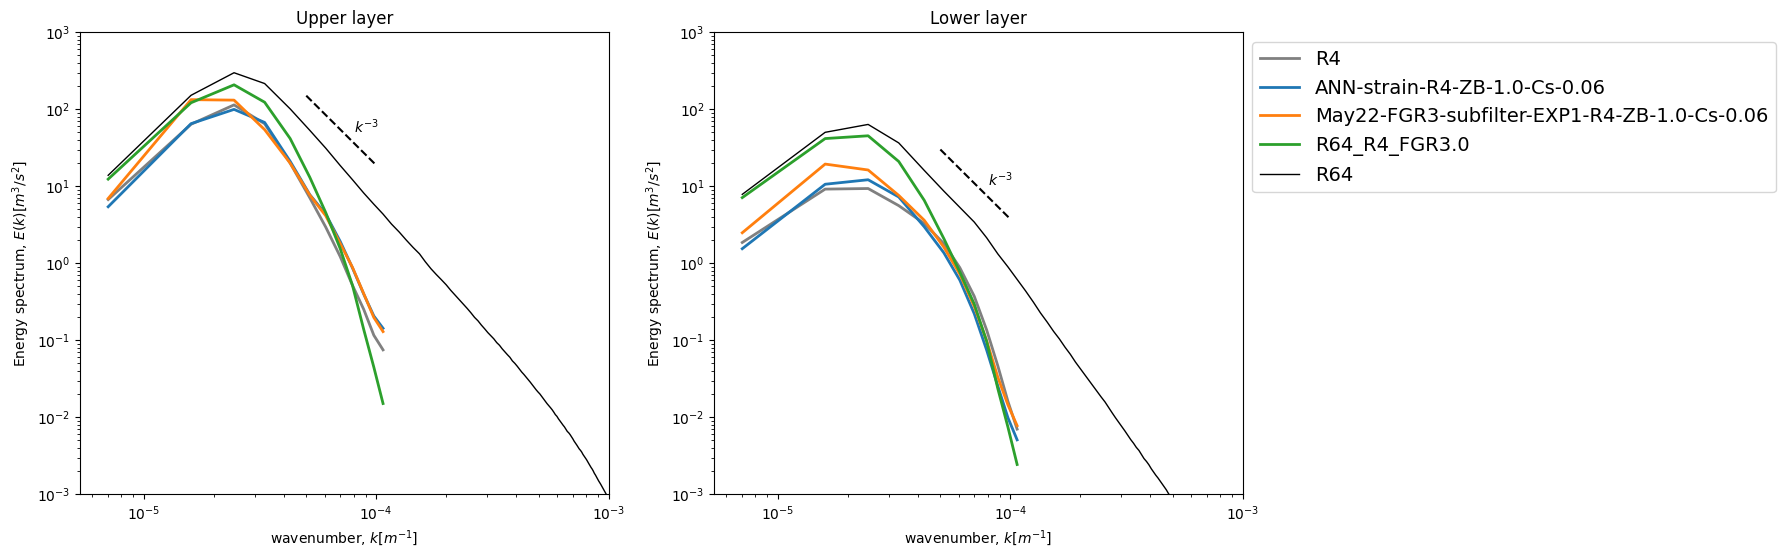

In [37]:
ds.plot_KE_spectrum(['R4', 'ANN-strain-R4-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R4-ZB-1.0-Cs-0.06', 'R64_R4_FGR3.0', 'R64'])

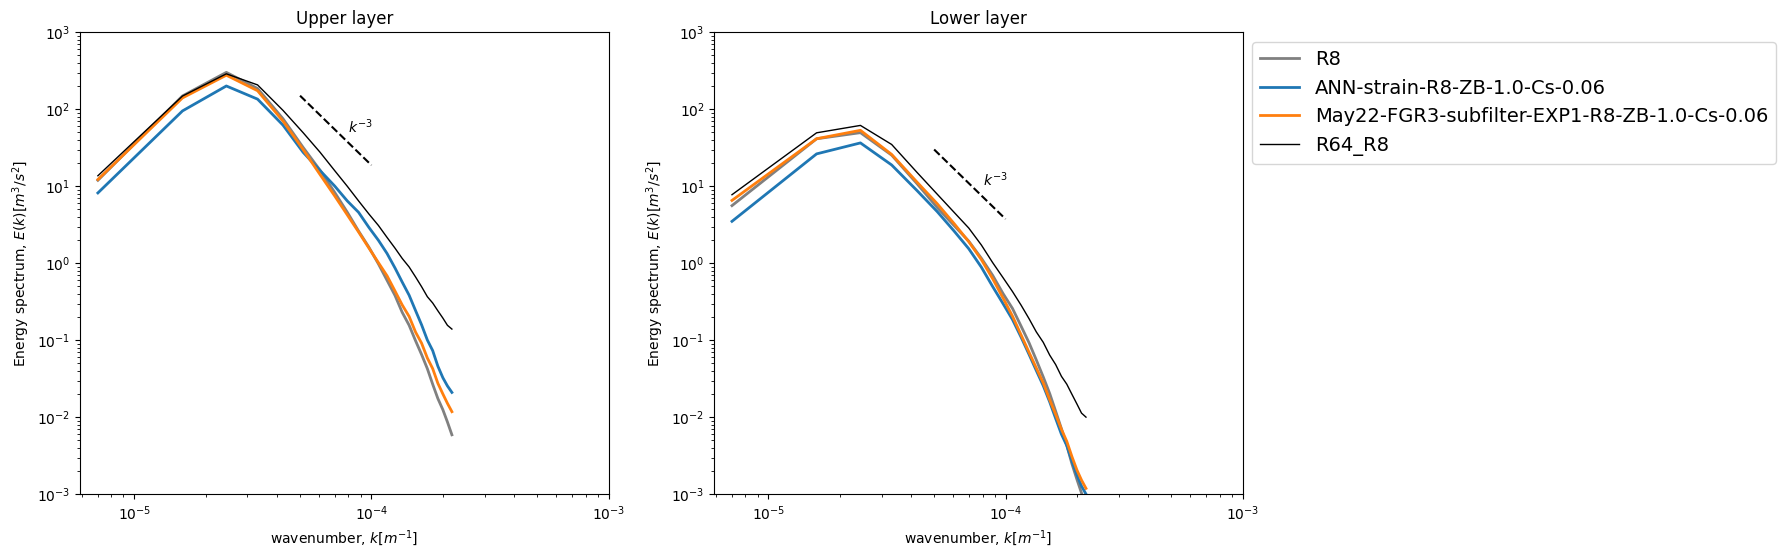

In [38]:
ds.plot_KE_spectrum(['R8', 'ANN-strain-R8-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R8-ZB-1.0-Cs-0.06', 'R64_R8'])

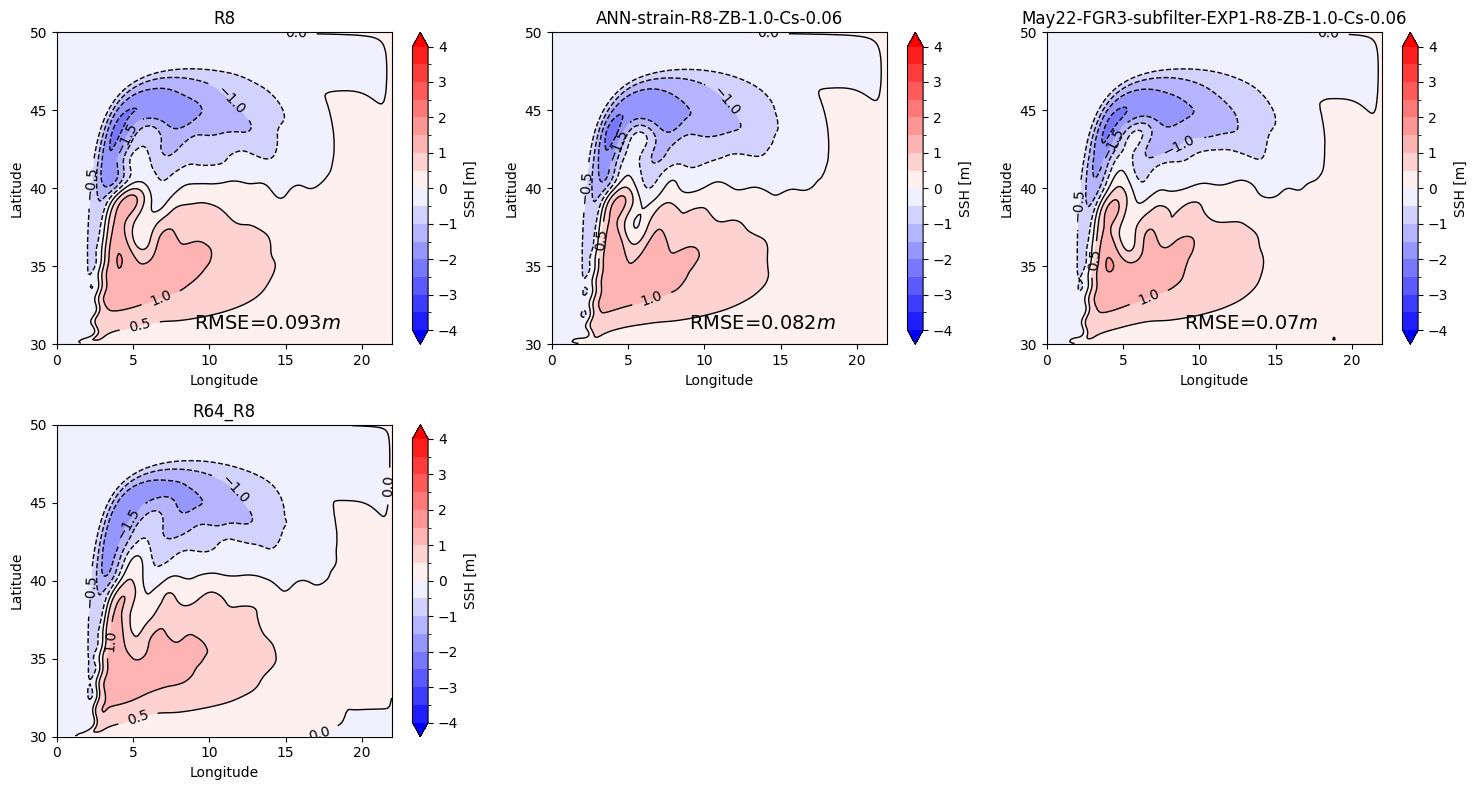

In [39]:
ds.plot_ssh(['R8', 'ANN-strain-R8-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R8-ZB-1.0-Cs-0.06', 'R64_R8'])

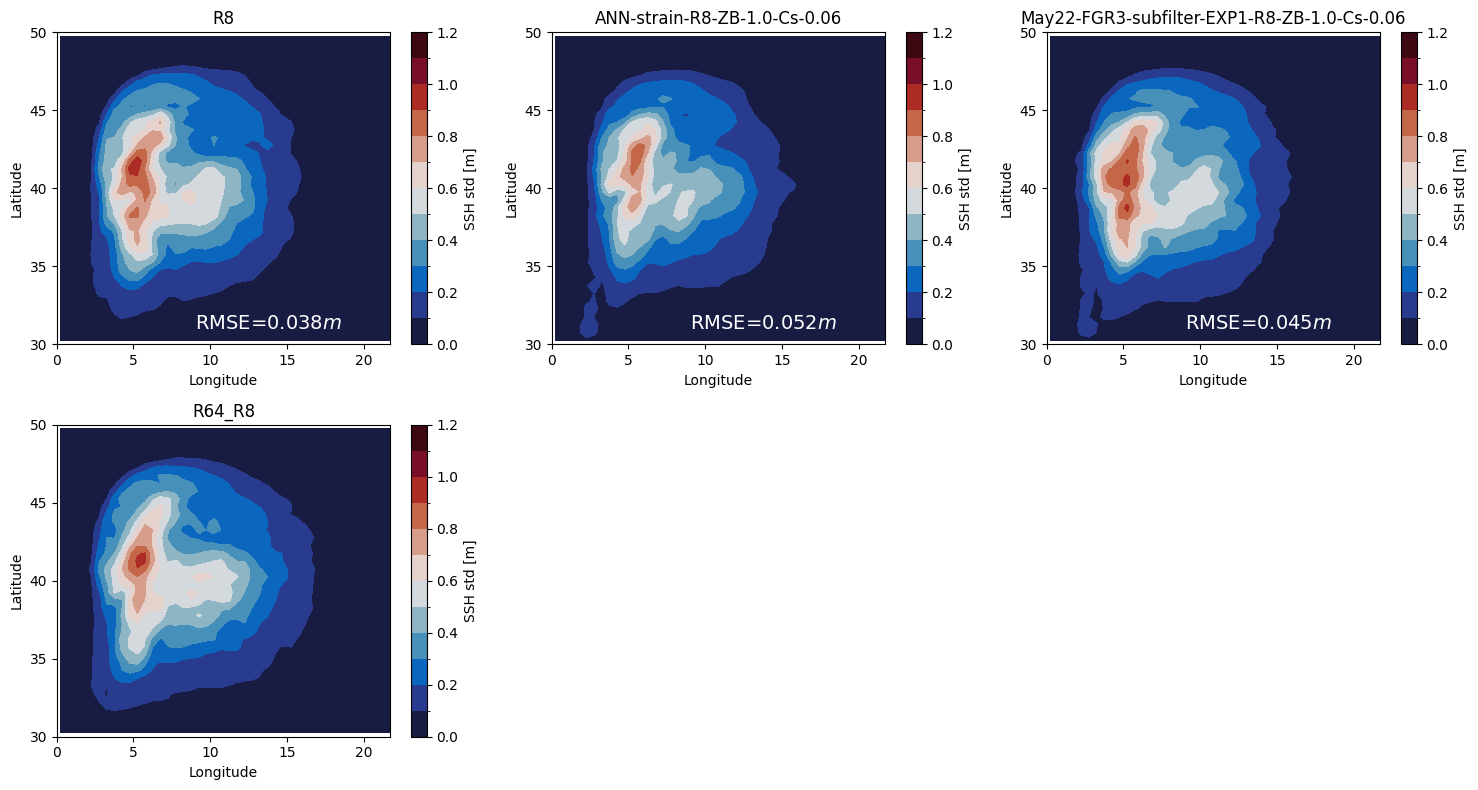

In [40]:
ds.plot_ssh_std(['R8', 'ANN-strain-R8-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R8-ZB-1.0-Cs-0.06', 'R64_R8'])

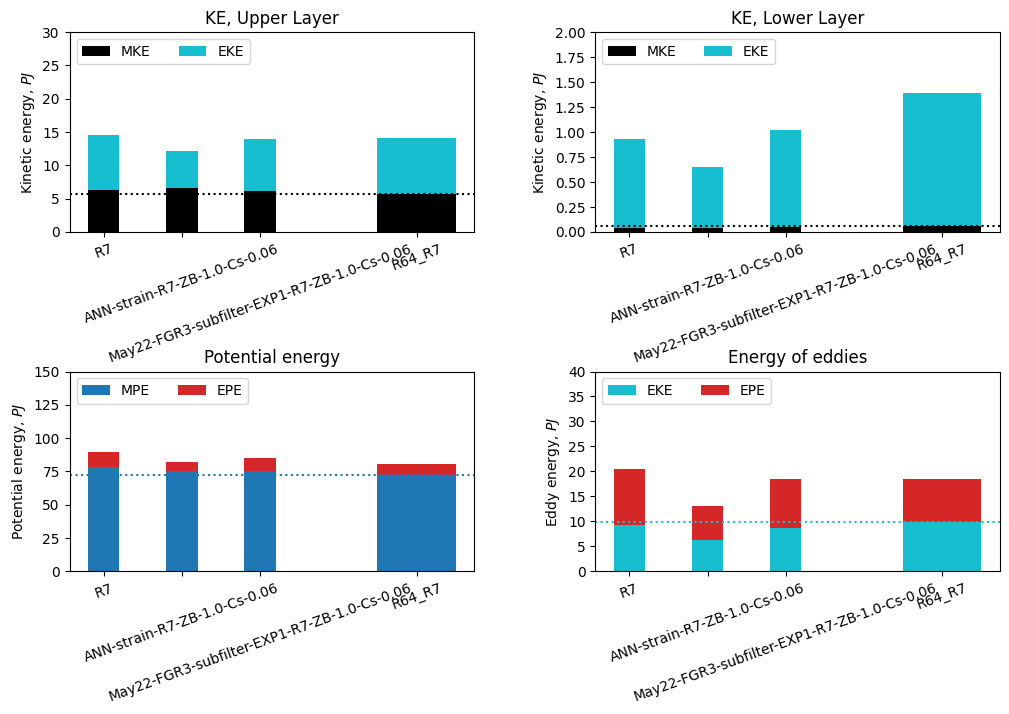

In [43]:
ds.plot_KE_PE(['R7', 'ANN-strain-R7-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP1-R7-ZB-1.0-Cs-0.06', 'R64_R7'])

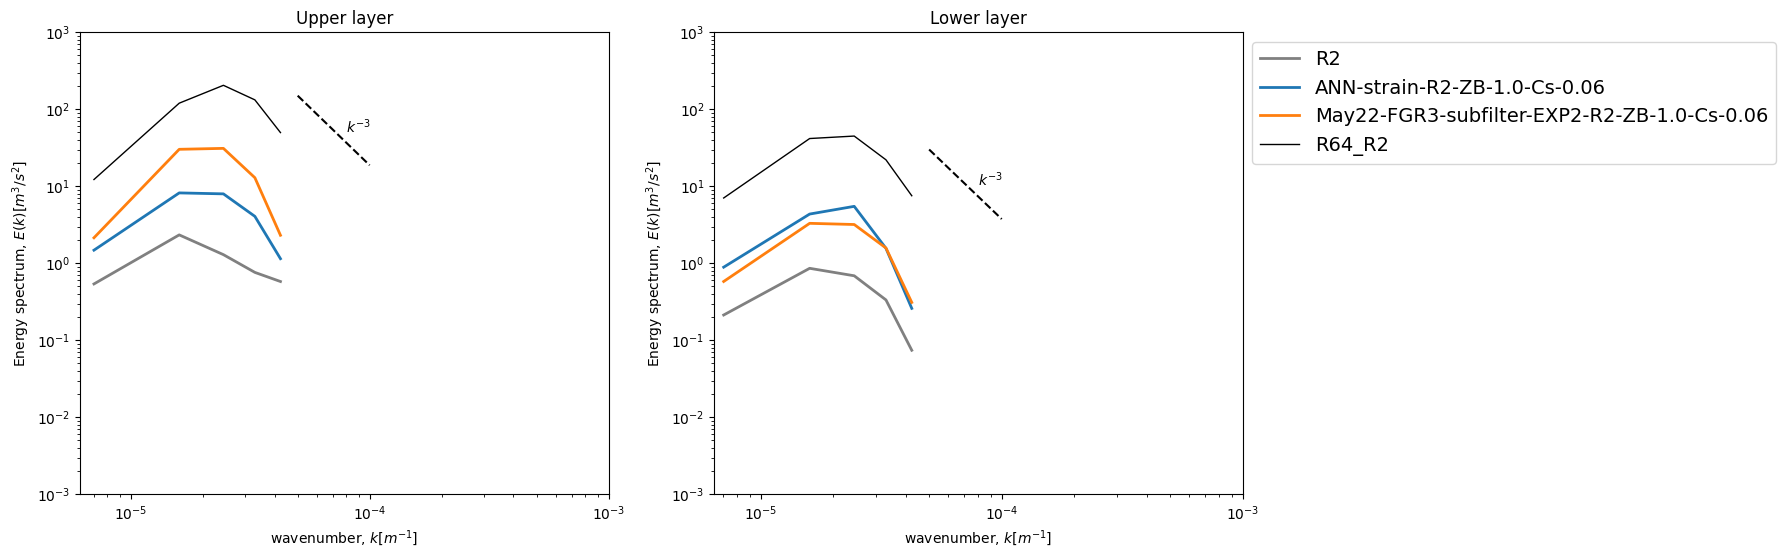

In [48]:
ds.plot_KE_spectrum(['R2', 'ANN-strain-R2-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R2-ZB-1.0-Cs-0.06', 'R64_R2'])

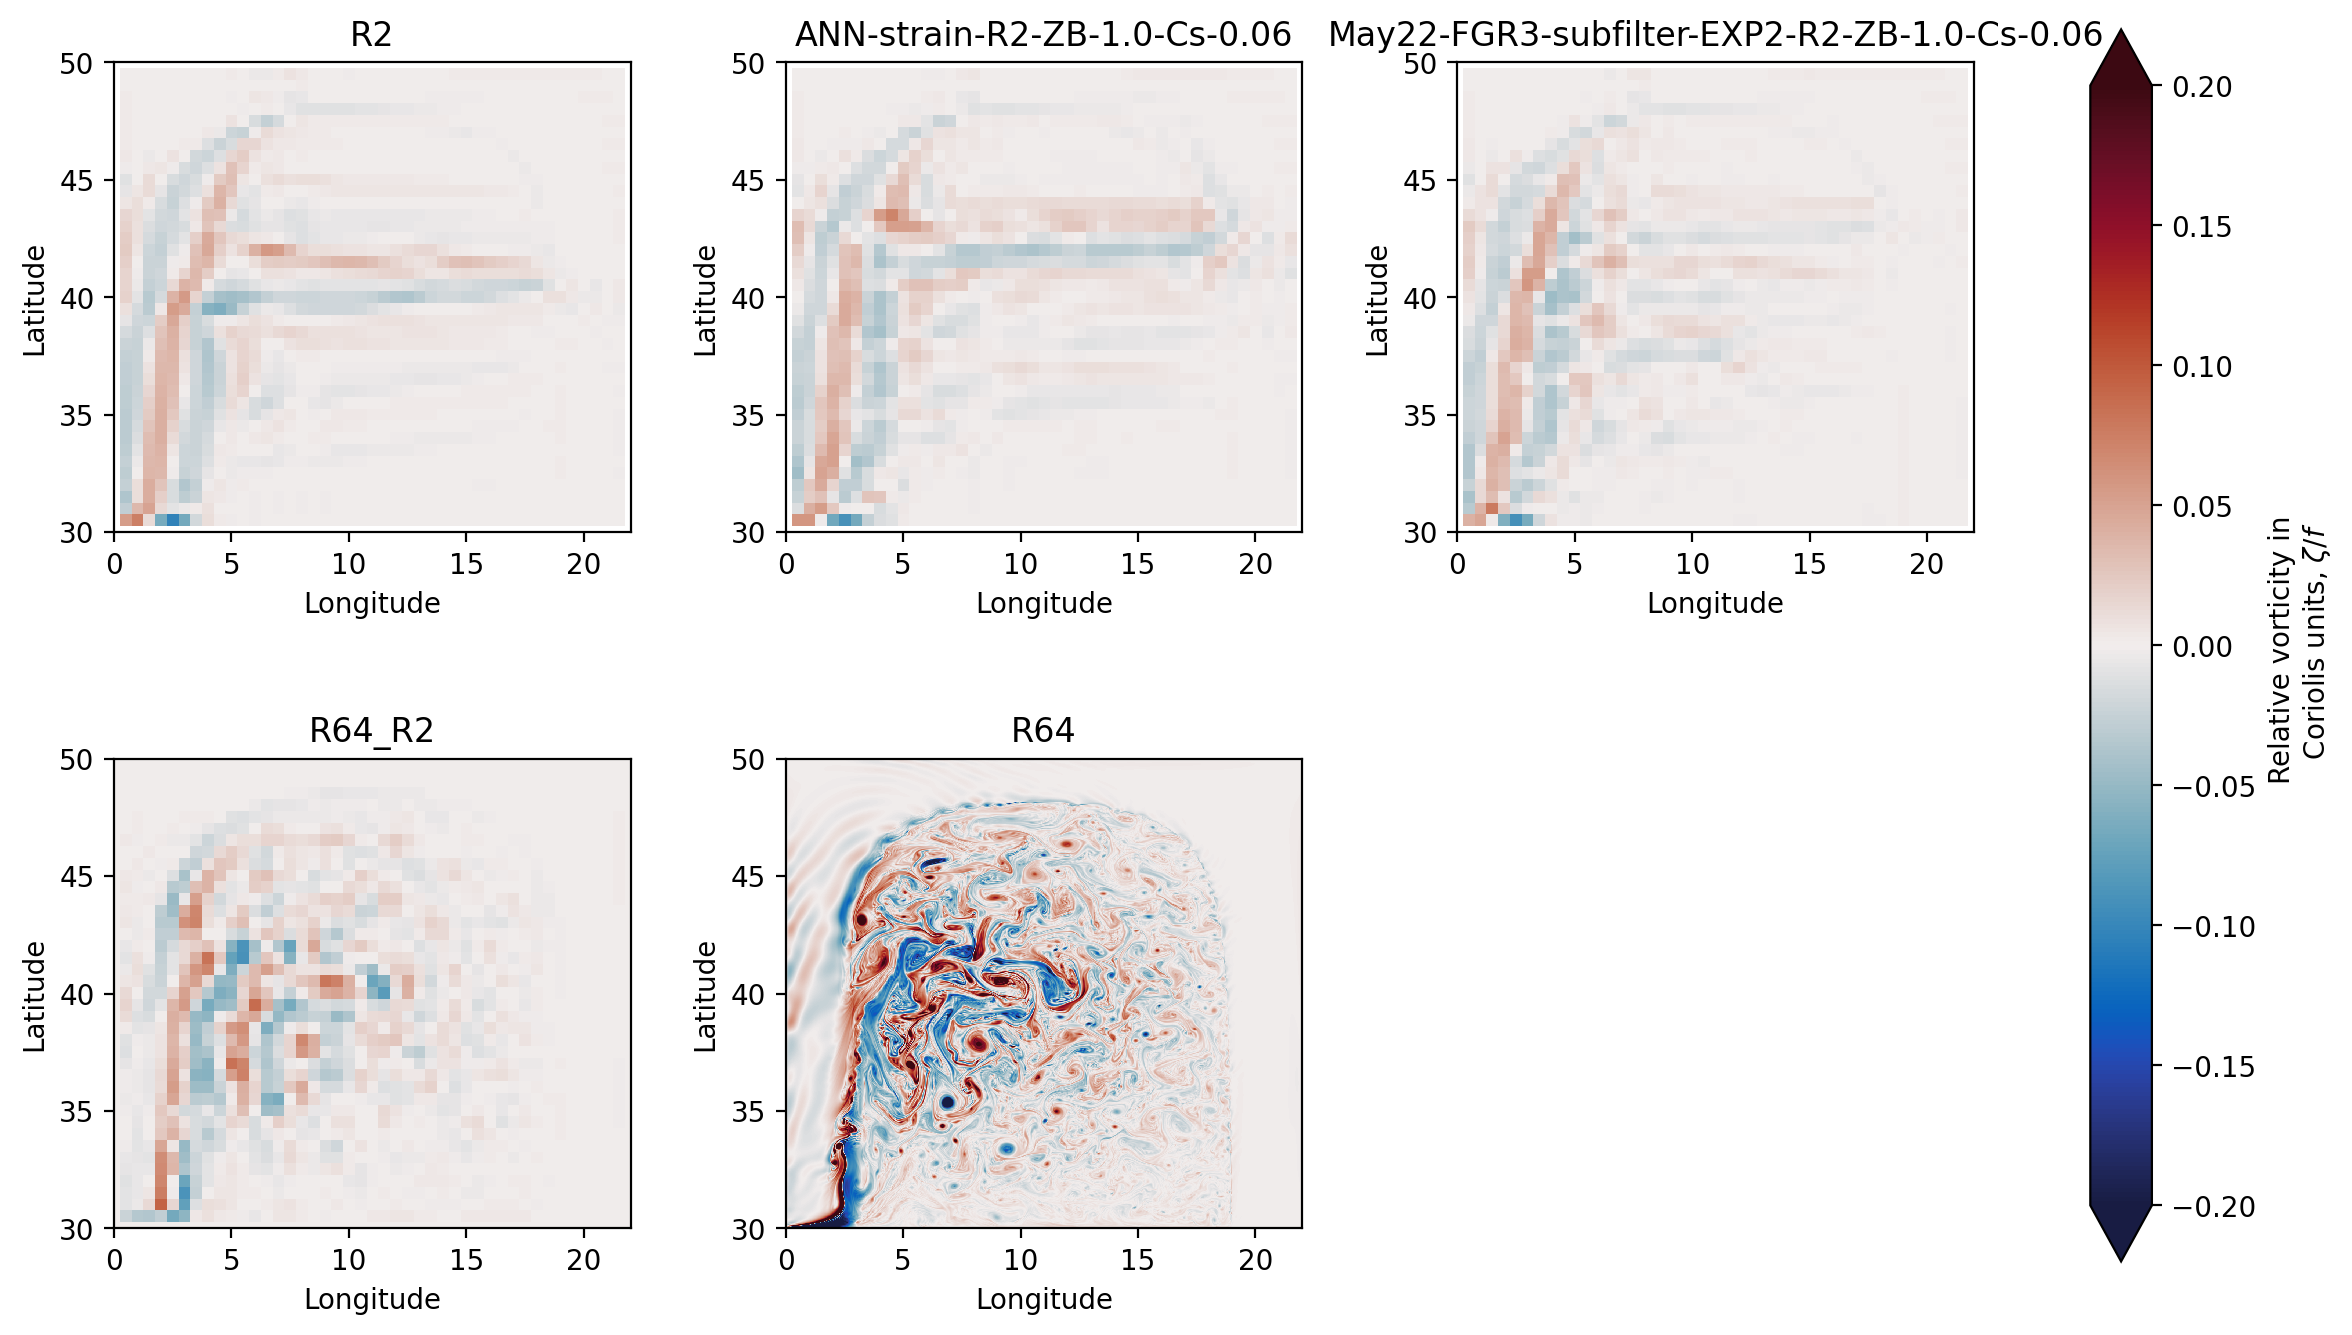

In [50]:
ds.plot_RV(['R2', 'ANN-strain-R2-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R2-ZB-1.0-Cs-0.06', 'R64_R2', 'R64'])

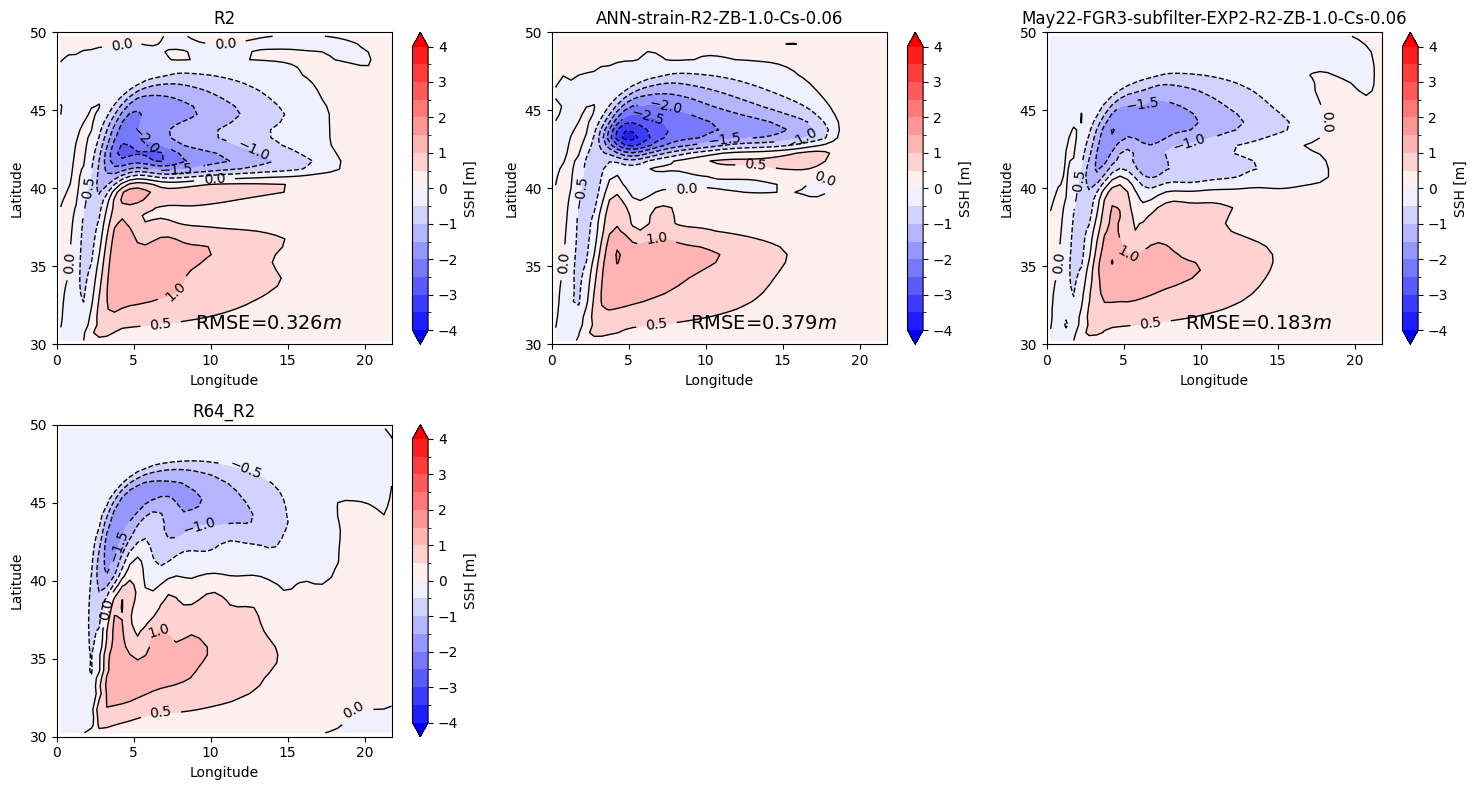

In [51]:
ds.plot_ssh(['R2', 'ANN-strain-R2-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R2-ZB-1.0-Cs-0.06', 'R64_R2'])

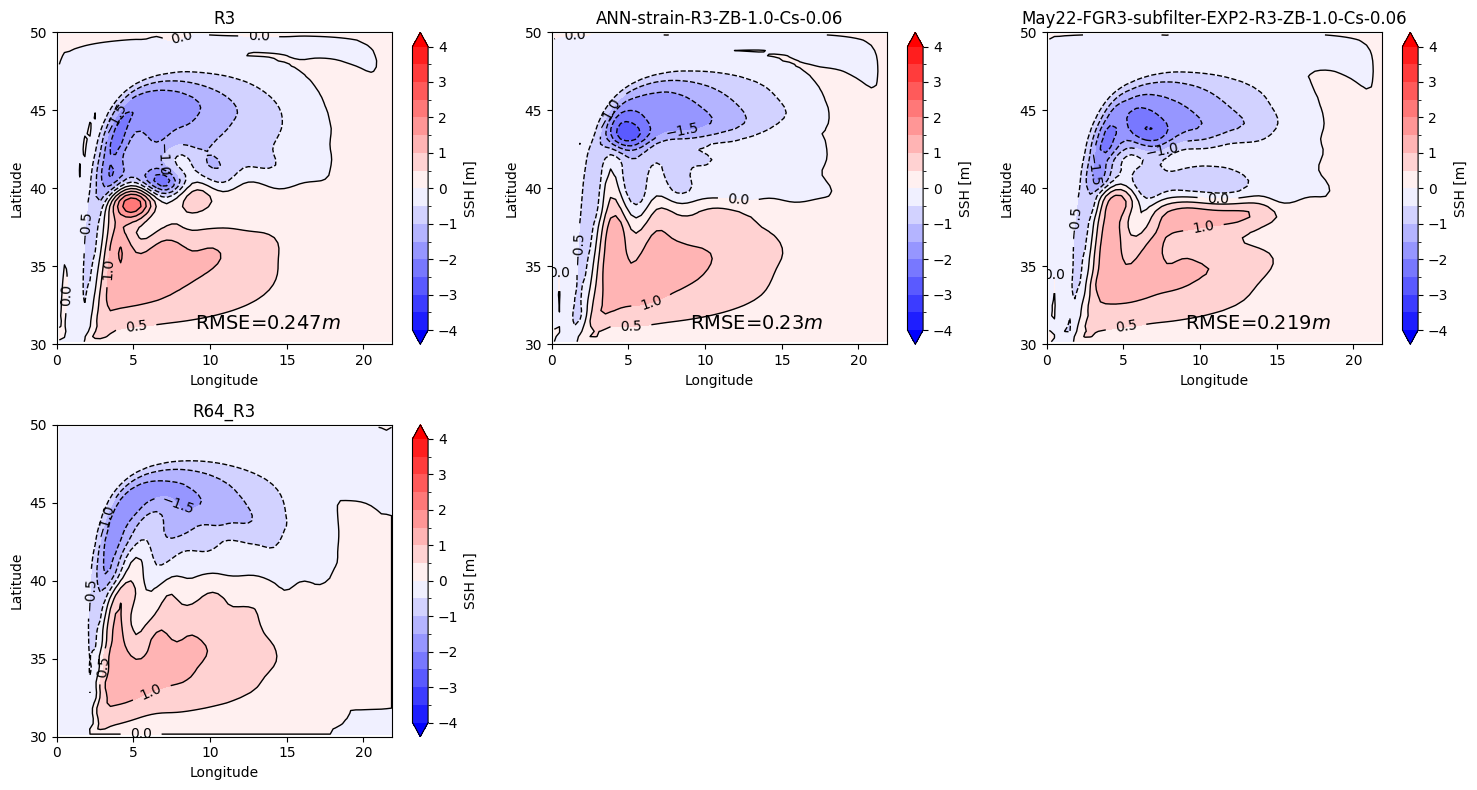

In [88]:
ds.plot_ssh(['R3', 'ANN-strain-R3-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R3-ZB-1.0-Cs-0.06', 'R64_R3'])

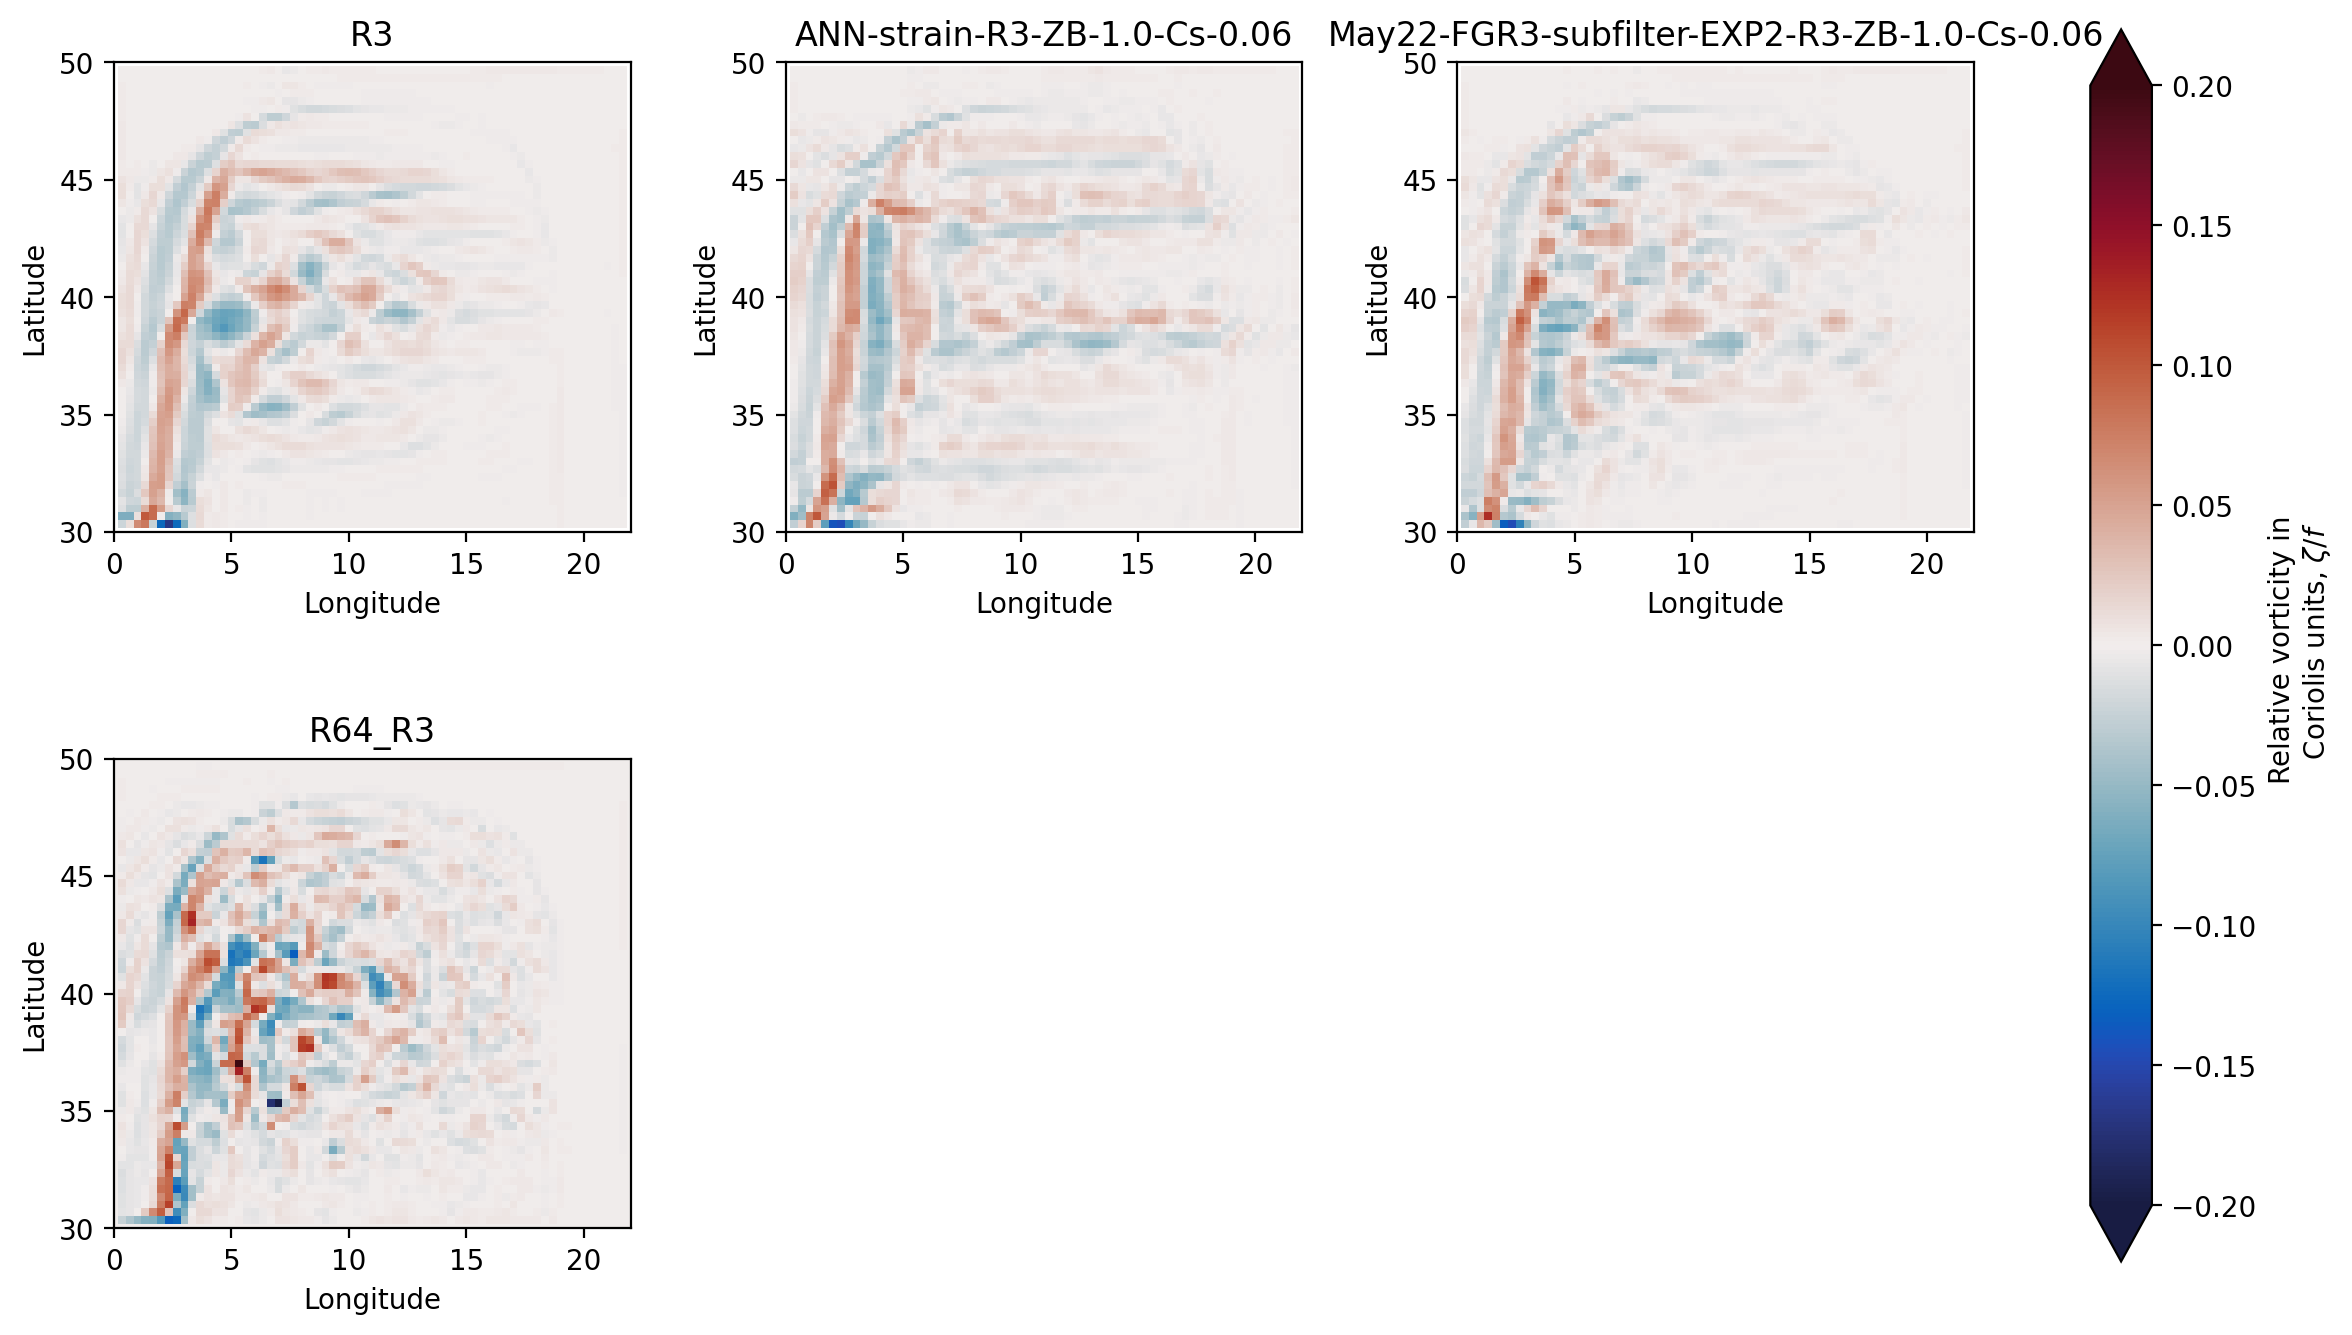

In [89]:
ds.plot_RV(['R3', 'ANN-strain-R3-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R3-ZB-1.0-Cs-0.06', 'R64_R3'])

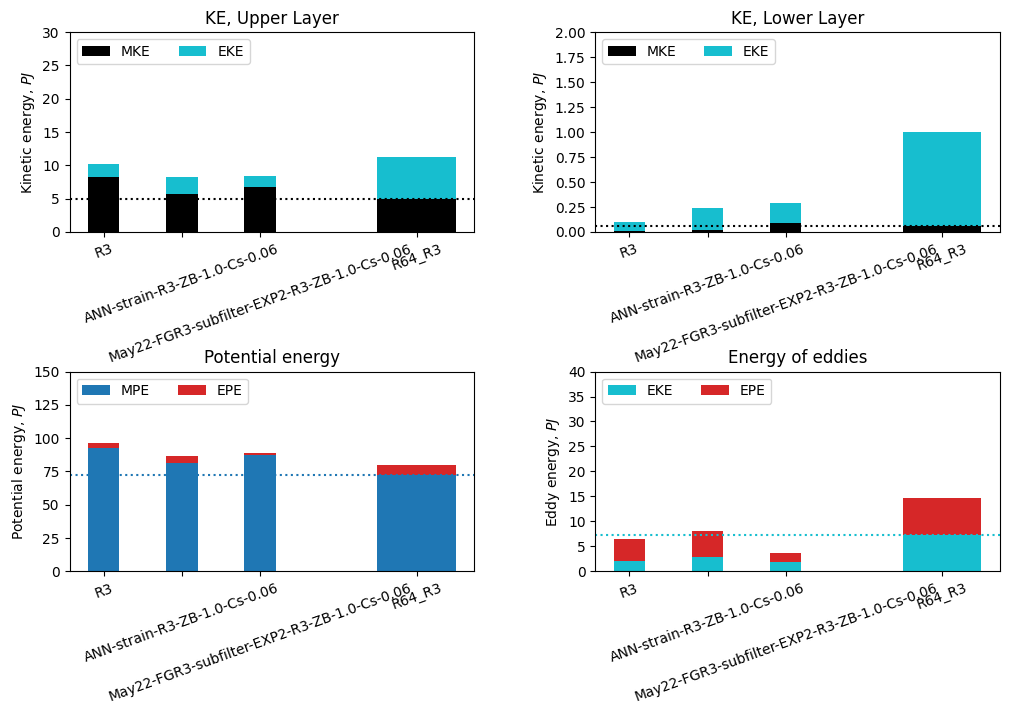

In [90]:
ds.plot_KE_PE(['R3', 'ANN-strain-R3-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R3-ZB-1.0-Cs-0.06', 'R64_R3'])

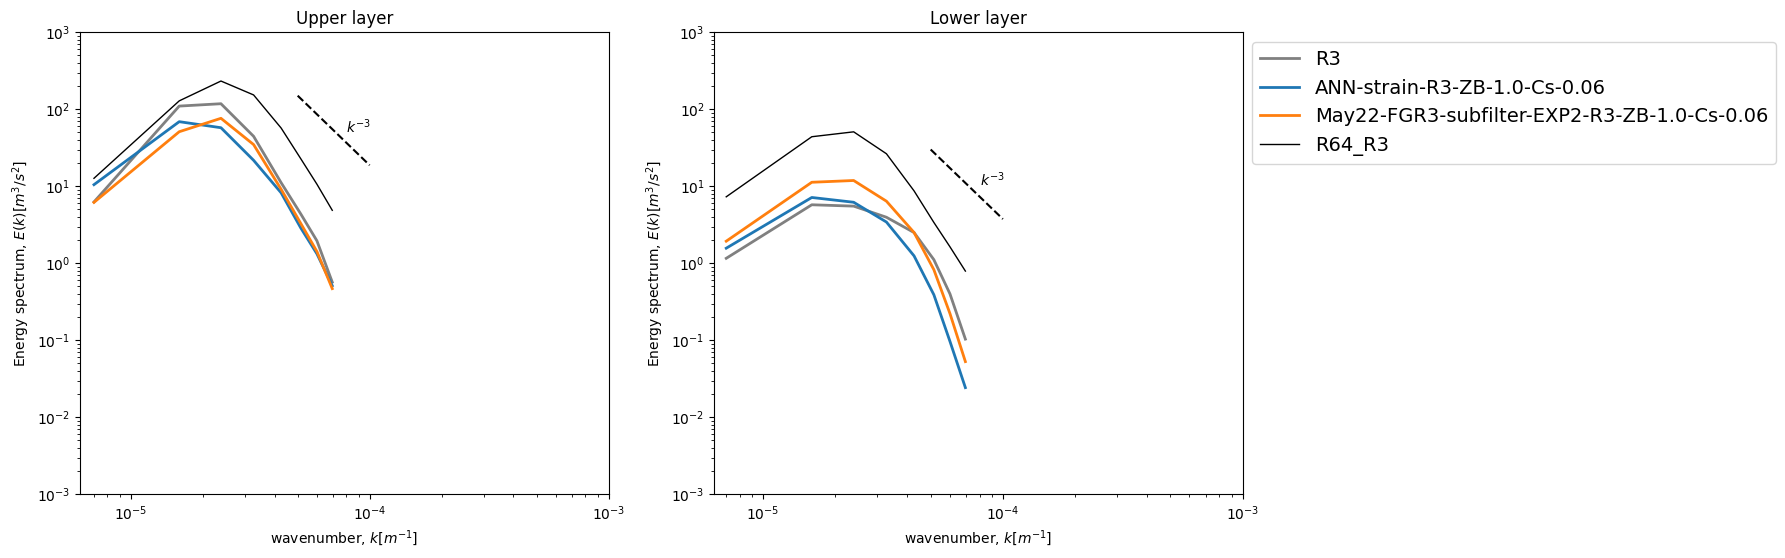

In [91]:
ds.plot_KE_spectrum(['R3', 'ANN-strain-R3-ZB-1.0-Cs-0.06', 'May22-FGR3-subfilter-EXP2-R3-ZB-1.0-Cs-0.06', 'R64_R3'])

In [92]:
def sample_ssh(exp, target):
    sample = []
    for year_start in [5, 10, 15]:
        try:
            year_end = year_start + 5
            idx = slice(365*year_start, 365*year_end)
            sample.append(
                Lk_error(ds[exp].ea.isel(zi=0).sel(Time=idx).mean('Time'), ds[target].ssh_mean)[0]
            )
        except:
            sample.append(np.nan)
    return xr.DataArray(sample, dims='sample')

In [99]:
def sample_KE(exp, target=None):
    sample = []
    for year_start in [5, 10, 15]:
        try:
            year_end = year_start + 5
            idx = slice(365*year_start, 365*year_end)
            u = ds[exp].u.sel(Time=idx)
            v = ds[exp].v.sel(Time=idx)
            h = ds[exp].h.sel(Time=idx)
    
            KE = 1e-15 * ds[exp].KE_joul(u, v, h).mean('Time').sum()
            sample.append(KE)
        except:
            sample.append(np.nan)
    return xr.DataArray(sample, dims='sample')

In [94]:
def sample_APE(exp, target=None):
    sample = []
    for year_start in [5, 10, 15]:
        try:
            year_end = year_start + 5
            idx = slice(365*year_start, 365*year_end)
            e = ds[exp].e.sel(Time=idx)
            APE = 1e-15 * (
                ds[exp].PE_joul(e).mean('Time').sum() + 
                ds[exp].PE_ssh(e).mean('Time').sum()
            )
            sample.append(APE)
        except:
            sample.append(np.nan)
    return xr.DataArray(sample, dims='sample')

In [95]:

def KE(exp, target=None):
    return 1e-15 * (ds[exp].MKE_joul + ds[exp].EKE_joul).sum('zl').values

def APE(exp, target=None):
    return 1e-15 * (ds[exp].MPE_joul + ds[exp].EPE_joul + ds[exp].MPE_ssh + ds[exp].EPE_ssh).values

In [97]:
error = {}

In [100]:
%%time
for fun, fun_str in zip([sample_KE, sample_APE, sample_ssh], ['KE', 'APE', 'ssh']):
    error[f'bare-{fun_str}'] = xr.concat([fun(conf,f'R64_{conf}') for conf in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']], dim='res')
    error[f'ZB-Smooth-{fun_str}'] = xr.concat([fun(f'ZB-Smooth-{conf}-ZB-1.0', f'R64_{conf}') for conf in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']], dim='res')

CPU times: user 33.7 s, sys: 3.87 s, total: 37.6 s
Wall time: 37 s


In [101]:
%%time
for fun, fun_str in zip([sample_KE, sample_APE, sample_ssh], ['KE', 'APE', 'ssh']):
    for FGR in [3]:
        for postfix in ['Cs-0.06']:
            for exp in ['EXP1', 'EXP2']:
                %time error[f'May22-FGR{FGR}-{exp}-{postfix}-{fun_str}'] = xr.concat([fun(f'May22-FGR{FGR}-subfilter-{exp}-{conf}-ZB-1.0-{postfix}', f'R64_{conf}') for conf in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']], dim='res')

CPU times: user 12.5 s, sys: 1.39 s, total: 13.9 s
Wall time: 8.86 s
CPU times: user 12.5 s, sys: 1.35 s, total: 13.9 s
Wall time: 8.97 s
CPU times: user 3.87 s, sys: 455 ms, total: 4.33 s
Wall time: 3.39 s
CPU times: user 3.17 s, sys: 419 ms, total: 3.59 s
Wall time: 2.66 s
CPU times: user 2.32 s, sys: 574 ms, total: 2.9 s
Wall time: 2.68 s
CPU times: user 2.23 s, sys: 581 ms, total: 2.81 s
Wall time: 3.17 s
CPU times: user 36.7 s, sys: 4.78 s, total: 41.4 s
Wall time: 29.7 s


In [102]:
%%time
for fun, fun_str in zip([sample_KE, sample_APE, sample_ssh], ['KE', 'APE', 'ssh']):
    %time error[f'ANN-strain-{fun_str}'] = xr.concat([fun(f'ANN-strain-{conf}-ZB-1.0-Cs-0.06', f'R64_{conf}') for conf in ['R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8']], dim='res')

CPU times: user 12.8 s, sys: 1.39 s, total: 14.2 s
Wall time: 9.4 s
CPU times: user 3.27 s, sys: 413 ms, total: 3.68 s
Wall time: 2.65 s
CPU times: user 3 s, sys: 683 ms, total: 3.68 s
Wall time: 4.02 s
CPU times: user 19 s, sys: 2.49 s, total: 21.5 s
Wall time: 16.1 s


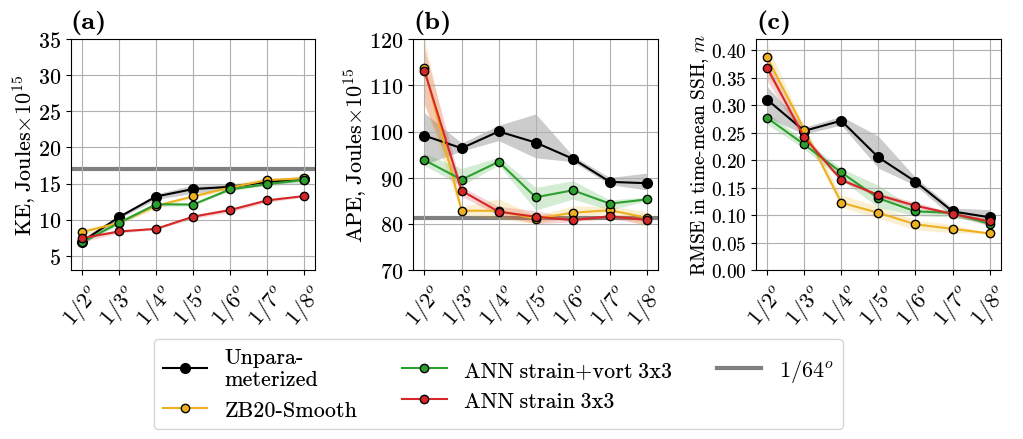

In [106]:
default_rcParams({'font.size': 16, 'figure.subplot.wspace': 0.4, 'figure.subplot.hspace': 0.1})
plt.figure(figsize=(12,3))

yellow = [0.9290, 0.6940, 0.1250]
violet = [0.4940, 0.1840, 0.5560]
lightblue = [0.3010, 0.7450, 0.9330]

for row, fun_str in enumerate(['KE', 'APE', 'ssh']):
    plt.subplot(1,3,row+1)

    def plot_markers_with_filling(model='Jansen-Held', color='tab:red', marker='s', label=None, markersize=None, lw=None):
        error[model].mean('sample').plot(color=color, marker=marker, label=label, markersize=markersize, markeredgecolor='k', lw=lw)
        plt.fill_between(range(7), error[model].min('sample'), error[model].max('sample'), color=color, alpha=0.2, lw=0)
    
    plot_markers_with_filling(f'bare-{fun_str}', 'k', 'o', 'Unpara-\nmeterized', 7)
    
    plot_markers_with_filling(f'ZB-Smooth-{fun_str}', yellow, 'o', 'ZB20-Smooth', 6)

    plot_markers_with_filling(f'May22-FGR3-EXP1-Cs-0.06-{fun_str}', 'tab:green', 'o', 'ANN strain+vort 3x3', 6)
    plot_markers_with_filling(f'ANN-strain-{fun_str}', 'tab:red', 'o', 'ANN strain 3x3', 6)
    
    plt.xticks([0,1,2,3,4,5,6], ['$1/2^o$', '$1/3^o$', '$1/4^o$', '$1/5^o$', '$1/6^o$', '$1/7^o$', '$1/8^o$'],rotation=50)    
    plt.grid()
    plt.xlabel('')
    if fun_str == 'KE':
        yticks = np.arange(5,40,5)
        plt.ylabel('KE, Joules$\\times10^{15}$')
        plt.yticks(yticks)
        plt.ylim([3,35])
        plt.axhline(y=KE('R64'),color='gray', zorder=-1,lw=3)
        #plt.text(0.0, 17.5,'$1/64^o$', color='gray')
    if fun_str == 'APE':
        yticks = np.arange(70,130,10)
        plt.ylabel('APE, Joules$\\times10^{15}$')
        plt.yticks(yticks)
        plt.ylim([min(yticks), max(yticks)])
        plt.axhline(y=APE('R64'),color='gray',zorder=-1,lw=3)
    
    if fun_str == 'ssh':
        yticks = np.arange(0,0.45,0.05)
        plt.ylabel('RMSE in time-mean SSH, $m$', fontsize=14)
        plt.yticks(yticks, fontsize=14)
        plt.ylim([0,0.42])

plt.gcf().align_ylabels()
set_letters(fontsize=18,x=0.0,y=1.05)
plt.plot(np.nan,np.nan,'-',color='gray',lw=3,label='$1/64^o$')
plt.legend(ncol=3, bbox_to_anchor=(0.4,-0.25))


#plt.suptitle('Second realization of training algorithm', y=1.1)
plt.savefig('metrics-ANN-strain.pdf')